In [1]:
import os
import glob
import random
import numpy as np
import nibabel as nib
from collections import Counter

import matplotlib.pyplot as plt
%matplotlib inline

# Interactive Jupyter widgets to visualize images, point sets, and meshes in 2D and 3D
import itk
import itkwidgets
# Jupyter interactive widgets
from ipywidgets import interact, interactive, ToggleButtons, IntSlider      

## Phase 1: Dataset Integrity

In [5]:
def verify_brats_dataset(root_dir):

    
    # Counters
    record_counts = {
        "patients": 0,
        "t1": 0,
        "t1ce": 0,
        "t2": 0,
        "flair": 0,
        "seg": 0
    }

    shape_counter = Counter()
    orientation_counter = Counter()
    voxel_counter = Counter()


    # Expected structure
    expected_modalities = {
        "t1",
        "t1ce",
        "t2",
        "flair",
        "seg"
    }


    missing_files = []
    shape_mismatches = []
    orientation_mismatches = []
    voxel_mismatches = []
    invalid_masks = []

    reference_shape = None
    reference_orientation = None
    reference_voxel_spacing = None


    patient_dirs = sorted(glob.glob(os.path.join(root_dir, "*")))

    for patient_dir in patient_dirs:

        if not os.path.isdir(patient_dir):
            continue

        record_counts["patients"] += 1

        patient_id = os.path.basename(patient_dir)

        files = glob.glob(os.path.join(patient_dir, "*.nii.gz"))

        found_modalities = set()

        
        # Check file presence
        for file in files:

            filename = os.path.basename(file)

            if filename.endswith("_t1.nii.gz"):
                found_modalities.add("t1")
                record_counts["t1"] += 1

            elif filename.endswith("_t1ce.nii.gz"):
                found_modalities.add("t1ce")
                record_counts["t1ce"] += 1

            elif filename.endswith("_t2.nii.gz"):
                found_modalities.add("t2")
                record_counts["t2"] += 1

            elif filename.endswith("_flair.nii.gz"):
                found_modalities.add("flair")
                record_counts["flair"] += 1

            elif filename.endswith("_seg.nii.gz"):
                found_modalities.add("seg")
                record_counts["seg"] += 1

        missing = expected_modalities - found_modalities

        if missing:
            missing_files.append(
                (patient_id, sorted(list(missing)))
            )


        # Metadata checks
        patient_shapes = []

        for file in files:

            img = nib.load(file)

            shape = img.shape
            orientation = nib.aff2axcodes(img.affine)
            voxel_spacing = img.header.get_zooms()

            patient_shapes.append(shape)

            shape_counter[shape] += 1
            orientation_counter[orientation] += 1
            voxel_counter[voxel_spacing] += 1

            if reference_shape is None:
                reference_shape = shape

            if reference_orientation is None:
                reference_orientation = orientation

            if reference_voxel_spacing is None:
                reference_voxel_spacing = voxel_spacing

            if shape != reference_shape:
                shape_mismatches.append(
                    (file, shape)
                )

            if orientation != reference_orientation:
                orientation_mismatches.append(
                    (file, orientation)
                )

            if voxel_spacing != reference_voxel_spacing:
                voxel_mismatches.append(
                    (file, voxel_spacing)
                )


            # Segmentation mask validation
            if file.endswith("_seg.nii.gz"):

                mask = img.get_fdata()

                labels = set(np.unique(mask))

                valid_labels = {0.0, 1.0, 2.0, 4.0}

                if not labels.issubset(valid_labels):
                    invalid_masks.append(
                        (patient_id, labels)
                    )

        # Within-patient shape consistency
        if len(set(patient_shapes)) != 1:

            shape_mismatches.append(
                (patient_id, "Modalities have different shapes")
            )


    # Report
    print("\n" + "=" * 60)
    print("BRATS DATASET INTEGRITY REPORT")
    print("=" * 60)

    print("\nDataset Summary")
    print("-" * 30)

    for k, v in record_counts.items():
        print(f"{k:10s}: {v}")

    print("\nUnique Shapes")
    print("-" * 30)

    for shape, count in shape_counter.items():
        print(f"{shape} : {count}")

    print("\nUnique Orientations")
    print("-" * 30)

    for orientation, count in orientation_counter.items():
        print(f"{orientation} : {count}")

    print("\nUnique Voxel Spacing")
    print("-" * 30)

    for voxel, count in voxel_counter.items():
        print(f"{voxel} : {count}")

    print("\nIntegrity Checks")
    print("-" * 30)

    print(f"Missing modality cases      : {len(missing_files)}")
    print(f"Shape mismatches           : {len(shape_mismatches)}")
    print(f"Orientation mismatches     : {len(orientation_mismatches)}")
    print(f"Voxel spacing mismatches   : {len(voxel_mismatches)}")
    print(f"Invalid segmentation masks : {len(invalid_masks)}")

    # Optional detailed output
    if missing_files:
        print("\nMissing Files Examples:")
        for item in missing_files[:5]:
            print(item)

    if invalid_masks:
        print("\nInvalid Mask Examples:")
        for item in invalid_masks[:5]:
            print(item)

    print("\nIntegrity check completed.")


# Usage
root_dir = "../dataset/brats_kaggle_2021/BraTS2021_Training_Data/"
verify_brats_dataset(root_dir)


BRATS DATASET INTEGRITY REPORT

Dataset Summary
------------------------------
patients  : 1251
t1        : 1251
t1ce      : 1251
t2        : 1251
flair     : 1251
seg       : 1251

Unique Shapes
------------------------------
(240, 240, 155) : 6255

Unique Orientations
------------------------------
('L', 'P', 'S') : 6255

Unique Voxel Spacing
------------------------------
(np.float32(1.0), np.float32(1.0), np.float32(1.0)) : 6255

Integrity Checks
------------------------------
Missing modality cases      : 0
Shape mismatches           : 0
Orientation mismatches     : 0
Voxel spacing mismatches   : 0
Invalid segmentation masks : 0

Integrity check completed.


In [39]:
# Class Frequency Analysis

def class_frequency_analysis(root_dir):

    records = []

    seg_files = glob.iglob(os.path.join(root_dir, "*", "*_seg.nii.gz"))

    for seg_file in seg_files:

        patient_id = os.path.basename(os.path.dirname(seg_file))

        mask = np.asarray(nib.load(seg_file).dataobj,dtype=np.uint8)

        labels, counts = np.unique(mask,return_counts=True)

        freq = dict(zip(labels, counts))

        records.append({
            "patient": patient_id,
            "background": freq.get(0, 0),
            "necrotic_tumor": freq.get(1, 0),
            "peritumoral_edema": freq.get(2, 0),
            "enhancing_tumor": freq.get(4, 0)
        })

    return records

records = class_frequency_analysis(root_dir)

total_bg = sum(r["background"] for r in records)
total_nt = sum(r["necrotic_tumor"] for r in records)
total_ed = sum(r["peritumoral_edema"] for r in records)
total_et = sum(r["enhancing_tumor"] for r in records)

total = total_bg + total_nt + total_ed + total_et

print(f"Background: {100*total_bg/total:.2f}%")
print(f"Necrotic  : {100*total_nt/total:.2f}%")
print(f"Edema     : {100*total_ed/total:.2f}%")
print(f"Enhancing : {100*total_et/total:.2f}%")

Background: 98.93%
Necrotic  : 0.16%
Edema     : 0.67%
Enhancing : 0.24%


## Phase 2: Visualization

Type of the image: <class 'nibabel.nifti1.Nifti1Image'>
Image Shape: (240, 240, 155)


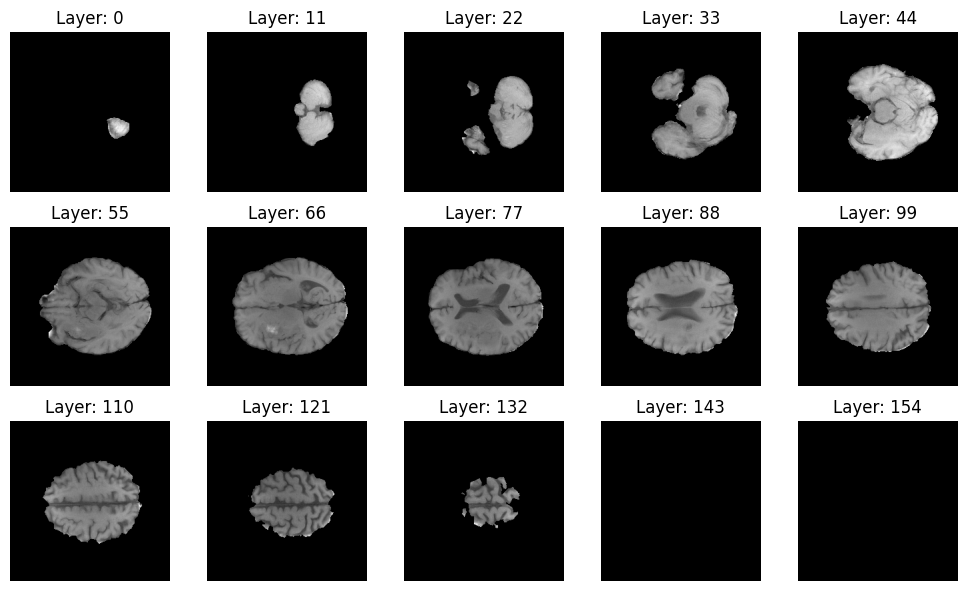

In [2]:
# visualize slices of brain
def show_slices(image_path):
    mri_img= nib.load(image_path)
    print(f"Type of the image: {type(mri_img)}")

    mri_img= mri_img.get_fdata()
    print(f"Image Shape: {mri_img.shape}")

    height, width, depth= mri_img.shape
    
    layers= np.linspace(0, 154, 15, dtype=int)
    
    fig, axes = plt.subplots(3, 5, figsize=(10, 6))
    for ax, layer in zip(axes.ravel(), layers):
        ax.imshow(mri_img[:,:, layer], cmap= "gray")
        ax.set_title(f"Layer: {layer}")
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()


img_path= "../dataset/brats_kaggle_2021/BraTS2021_Training_Data/BraTS2021_00026/BraTS2021_00026_t1.nii.gz"
show_slices(img_path)

In [2]:
mri_data = nib.load('../dataset/Original/BraTS2021_Training_Data/BraTS2021_00709/BraTS2021_00709_flair.nii.gz').get_fdata()
mask_data = nib.load('../dataset/Original/BraTS2021_Training_Data/BraTS2021_00709/BraTS2021_00709_seg.nii.gz').get_fdata()


classes_dict = {
    "Normal":0,
    "Non-Enhancing Tumor":1,
    "Edema":2,
    "Enhancing Tumor":3
}


select_class = ToggleButtons(
    options=list(classes_dict.keys()),
    description="Select Class",
    disabled=False,
    button_style="info"
)


select_layer = IntSlider(
    min=0,
    max=mri_data.shape[2]-1,
    description="Select Layer",
    continuous_update=False
)


def show_image(seg_class, layer):

    class_id = classes_dict[seg_class]

    print(f"Plotting Layer: {layer}, Label: {seg_class}")

    mri_slice = mri_data[:, :, layer]
    mask_slice = mask_data[:, :, layer]

    # select only chosen class
    class_mask = np.where(mask_slice == class_id, 1, 0)

    # hide background
    masked_annotation = np.ma.masked_where(class_mask == 0,class_mask)

    plt.figure(figsize=(6,6))
    plt.imshow(mri_slice.T,cmap="gray",origin="lower")
    plt.imshow(masked_annotation.T,cmap="jet",alpha=0.5,origin="lower")


    plt.title(f"{seg_class} - Slice {layer}")

    plt.axis("off")

    plt.show()



interactive(show_image,seg_class=select_class,layer=select_layer)

interactive(children=(ToggleButtons(button_style='info', description='Select Class', options=('Normal', 'Non-E…